## Sample

开始处理目录: F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\reserves_picture_liqudation
找到了 42 个 JSON 文件。开始处理...

数据处理完成。

--- 正在生成图表 1: 时间间隔 ---


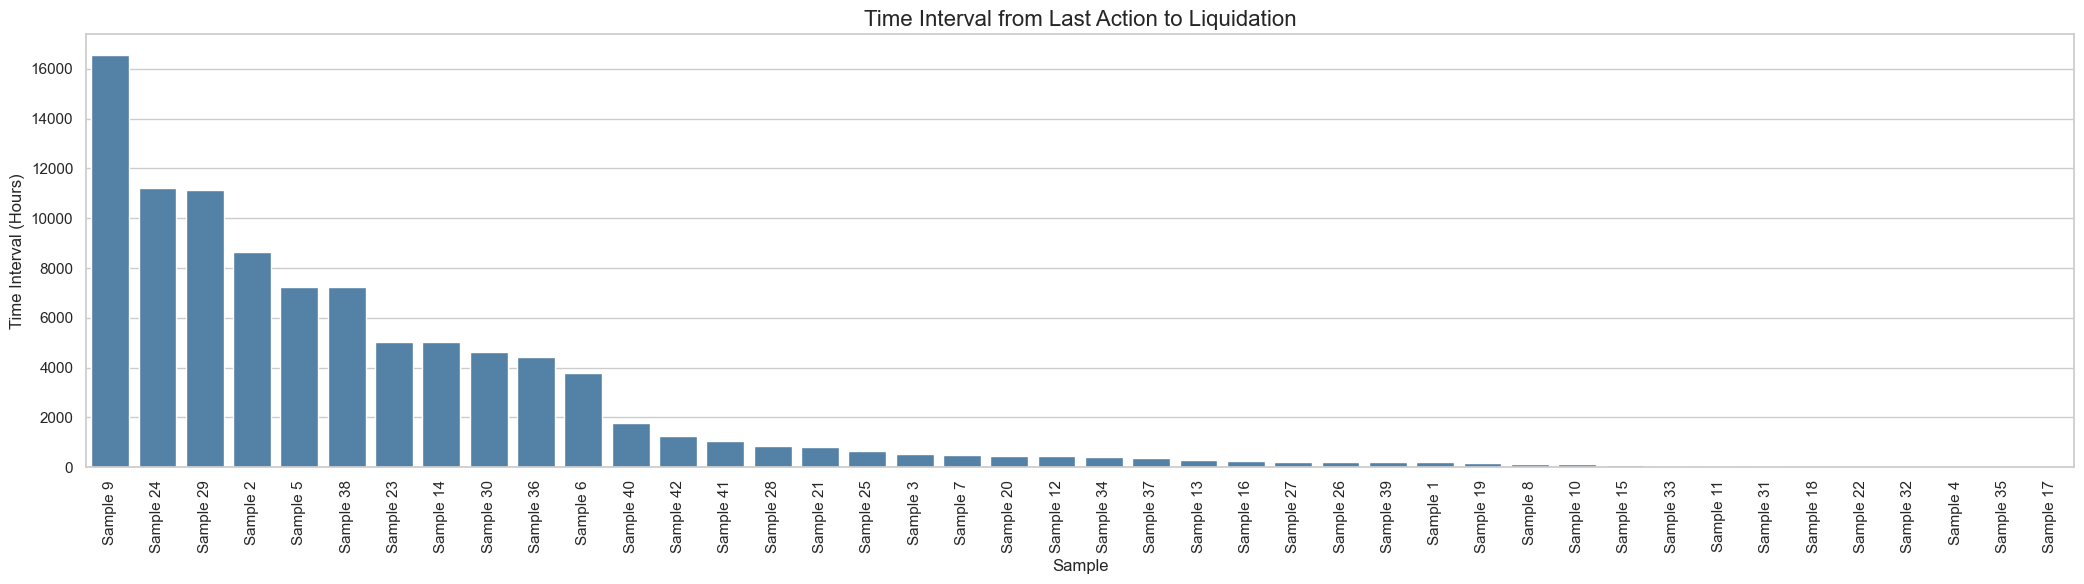


--- 正在生成图表 2: 抵押物与债务 ---


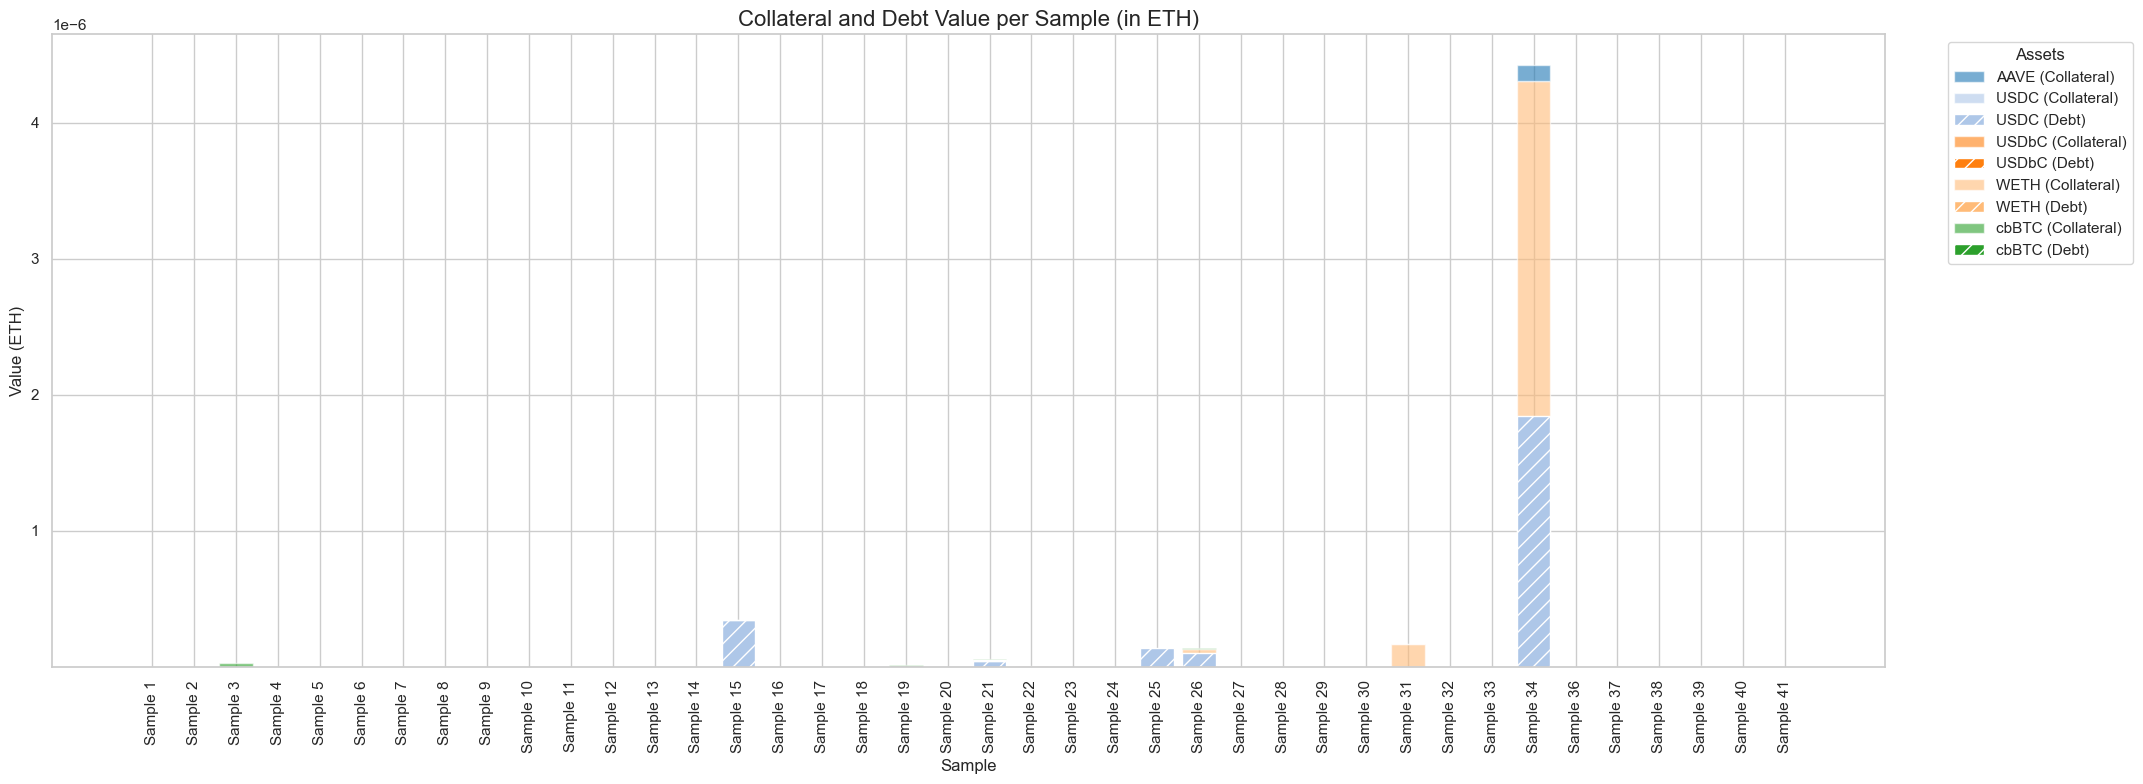


--- 所有操作已完成 ---


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from pathlib import Path
from decimal import Decimal, getcontext
import warnings
from matplotlib.patches import Patch # 导入 Patch 用于手动创建图例

# --- 0. 设置 ---

# 设置 Decimal 的精度以处理大型货币数字
getcontext().prec = 50

# 设置 Seaborn 样式
sns.set_theme(style="whitegrid")

# 忽略 Matplotlib 的 UserWarning (如果图例句柄过多)
warnings.filterwarnings("ignore", category=UserWarning)

# --- 1. 定义 JSON 目录 (请确保此路径在您的环境中正确) ---
# 这是您提供的路径
JSON_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\reserves_picture_liqudation")

print(f"开始处理目录: {JSON_DIR}")

# --- 2. 数据加载和处理 ---

def calculate_eth_value(balance_str, price_str, decimals):
    """
    使用 Decimal 精确计算 ETH 市值。
    公式: value_eth = (balance_wei * price_in_eth_wei) / (10^decimals * 10^18)
    """
    try:
        balance_wei = Decimal(balance_str)
        price_in_eth_wei = Decimal(price_str)
        
        if balance_wei == 0 or price_in_eth_wei == 0:
            return Decimal(0)
            
        # 10^decimals
        denominator_decimals = Decimal(10) ** int(decimals)
        # 10^18 (priceInEth 的单位)
        denominator_price = Decimal(10) ** 18
        
        value_eth = (balance_wei * price_in_eth_wei) / (denominator_decimals * denominator_price)
        return value_eth
        
    except Exception as e:
        print(f"警告: 计算市值时出错 (balance: {balance_str}, price: {price_str}, decimals: {decimals}). 错误: {e}")
        return Decimal(0)

# 存储所有样本数据的列表
all_samples_data = []
# 存储资产明细 (长格式) 的列表
all_assets_data = []

# 查找所有 JSON 文件
json_files = sorted(glob.glob(str(JSON_DIR / "*.json")))

if not json_files:
    print(f"警告：在 {JSON_DIR} 中未找到 .json 文件。请检查路径是否正确以及文件是否已生成。")
else:
    print(f"找到了 {len(json_files)} 个 JSON 文件。开始处理...")

    for i, file_path in enumerate(json_files):
        sample_name = f"Sample {i + 1}"
        
        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                print(f"警告: 跳过 {file_path}，因为文件 JSON 格式无效。")
                continue

        # 1. 计算时间间隔
        try:
            liquidation_ts = Decimal(data['liquidation_timestamp'])
            last_action_ts = Decimal(data['last_action_timestamp'])
            time_diff_seconds = float(liquidation_ts - last_action_ts)
            # 转换为小时以便阅读
            time_diff_hours = time_diff_seconds / 3600.0
        except (KeyError, TypeError):
            print(f"警告: 跳过 {sample_name} 的时间计算，缺少 'liquidation_timestamp' 或 'last_action_timestamp'。")
            time_diff_hours = 0.0

        # 2. 计算抵押物和债务
        if 'liquidation_snapshot' not in data:
            print(f"警告: 跳过 {sample_name} 的资产计算，缺少 'liquidation_snapshot'。")
            continue

        for asset in data['liquidation_snapshot']:
            try:
                symbol = asset['reserve']['symbol']
                decimals = asset['reserve']['decimals']
                price_eth_str = asset['reserve']['price']['priceInEth']
                is_collateral = asset['usageAsCollateralEnabledOnUser']
                
                balance_str = asset['currentATokenBalance']
                debt_str = asset['currentTotalDebt']

                # 计算抵押物价值
                collateral_value_eth = calculate_eth_value(balance_str, price_eth_str, decimals)
                if is_collateral and collateral_value_eth > 0:
                    all_assets_data.append({
                        "sample_name": sample_name,
                        "asset_symbol": symbol,
                        "value_eth_float": float(collateral_value_eth),
                        "type": "Collateral"
                    })

                # 计算债务价值
                debt_value_eth = calculate_eth_value(debt_str, price_eth_str, decimals)
                if debt_value_eth > 0:
                    all_assets_data.append({
                        "sample_name": sample_name,
                        "asset_symbol": symbol,
                        "value_eth_float": float(debt_value_eth),
                        "type": "Debt"
                    })
                    
            except (KeyError, TypeError) as e:
                print(f"警告: 处理 {sample_name} 中的资产时出错 (Symbol: {asset.get('reserve', {}).get('symbol', 'N/A')}). 错误: {e}")

        all_samples_data.append({
            "sample_name": sample_name,
            "time_diff_hours": time_diff_hours
        })

# --- 3. 转换为 DataFrame ---

df_samples = pd.DataFrame(all_samples_data)
df_assets_long = pd.DataFrame(all_assets_data)

print("\n数据处理完成。")
if df_samples.empty:
    print("未加载任何样本数据，无法生成图表。")
if df_assets_long.empty:
    print("未加载任何资产数据，无法生成图表。")

# --- 4. 可视化 1: 时间间隔柱状图 ---

if not df_samples.empty:
    print("\n--- 正在生成图表 1: 时间间隔 ---")
    
    # 动态调整图表宽度
    num_samples = len(df_samples['sample_name'].unique())
    chart_width = max(10, num_samples * 0.5)
    
    plt.figure(figsize=(chart_width, 6))
    
    # 按时间间隔排序以便查看
    df_samples_sorted = df_samples.sort_values('time_diff_hours', ascending=False)
    
    ax1 = sns.barplot(
        data=df_samples_sorted,
        x='sample_name',
        y='time_diff_hours',
        color='steelblue'
    )
    
    ax1.set_title('Time Interval from Last Action to Liquidation', fontsize=16)
    ax1.set_xlabel('Sample', fontsize=12)
    ax1.set_ylabel('Time Interval (Hours)', fontsize=12)
    
    # 如果样本太多，旋转标签
    if num_samples > 15:
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
    
    plt.tight_layout()
    # 遵照您的要求，已移除 plt.savefig()
    plt.show() # 在 Notebook 中显示

# --- 5. 可视化 2: 抵押物/债务堆叠柱状图 (使用 Matplotlib) ---

if not df_assets_long.empty:
    print("\n--- 正在生成图表 2: 抵押物与债务 ---")

    # 准备数据
    unique_samples = sorted(df_assets_long['sample_name'].unique(), key=lambda x: int(x.split(' ')[1]))
    unique_assets = sorted(df_assets_long['asset_symbol'].unique())
    
    # 创建颜色映射
    # 使用 'tab20' colormap，因为它有更多颜色
    palette = sns.color_palette('tab20', n_colors=len(unique_assets))
    color_map = {asset: color for asset, color in zip(unique_assets, palette)}

    # 动态调整图表宽度
    chart_width_2 = max(12, len(unique_samples) * 0.6)
    
    fig, ax = plt.subplots(figsize=(chart_width_2, 8))

    # 用于堆叠的底部追踪
    collateral_bottoms = {sample: 0.0 for sample in unique_samples}
    debt_bottoms = {sample: 0.0 for sample in unique_samples}
    
    # 绘制抵押物 (半透明)
    df_collateral = df_assets_long[df_assets_long['type'] == 'Collateral']
    for _, row in df_collateral.iterrows():
        sample = row['sample_name']
        symbol = row['asset_symbol']
        value = row['value_eth_float']
        color = color_map[symbol]

        ax.bar(
            sample,
            value,
            bottom=collateral_bottoms[sample],
            color=color,
            alpha=0.6 # 半透明
        )
        collateral_bottoms[sample] += value

    # 绘制债务 (不透明)
    df_debt = df_assets_long[df_assets_long['type'] == 'Debt']
    for _, row in df_debt.iterrows():
        sample = row['sample_name']
        symbol = row['asset_symbol']
        value = row['value_eth_float']
        color = color_map[symbol]
        
        ax.bar(
            sample,
            value,
            bottom=debt_bottoms[sample],
            color=color,
            alpha=1.0, # 不透明
            hatch='//' # 添加斜线以区分
        )
        debt_bottoms[sample] += value

    ax.set_title('Collateral and Debt Value per Sample (in ETH)', fontsize=16)
    ax.set_xlabel('Sample', fontsize=12)
    ax.set_ylabel('Value (ETH)', fontsize=12)
    
    # 如果样本太多，旋转标签
    if len(unique_samples) > 15:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    # --- (!! 修复图例 !!) ---
    # 手动为图例创建 Patch (色块)
    legend_handles = []
    
    # 找出所有被绘制过的 (资产, 类型) 组合
    plotted_assets = df_assets_long.groupby(['asset_symbol', 'type']).size().reset_index().drop(0, axis=1)
    # 按资产名称和类型排序
    plotted_assets = plotted_assets.sort_values(by=['asset_symbol', 'type'])

    for _, row in plotted_assets.iterrows():
        symbol = row['asset_symbol']
        asset_type = row['type']
        color = color_map[symbol]
        
        if asset_type == 'Collateral':
            handle = Patch(
                facecolor=color,
                alpha=0.6,
                label=f"{symbol} (Collateral)"
            )
        else: # Debt
            handle = Patch(
                facecolor=color,
                alpha=1.0,
                hatch='//',
                label=f"{symbol} (Debt)"
            )
        legend_handles.append(handle)

    # 使用手动创建的句柄列表生成图例
    ax.legend(handles=legend_handles, title='Assets', bbox_to_anchor=(1.03, 1), loc='upper left')

    # 调整布局以适应图例
    fig.tight_layout(rect=[0, 0, 0.9, 1]) 
    
    # 遵照您的要求，已移除 plt.savefig()
    plt.show() # 在 Notebook 中显示

print("\n--- 所有操作已完成 ---")

--- 正在生成图表 3: 资产构成百分比 (100% 堆叠柱状图) ---


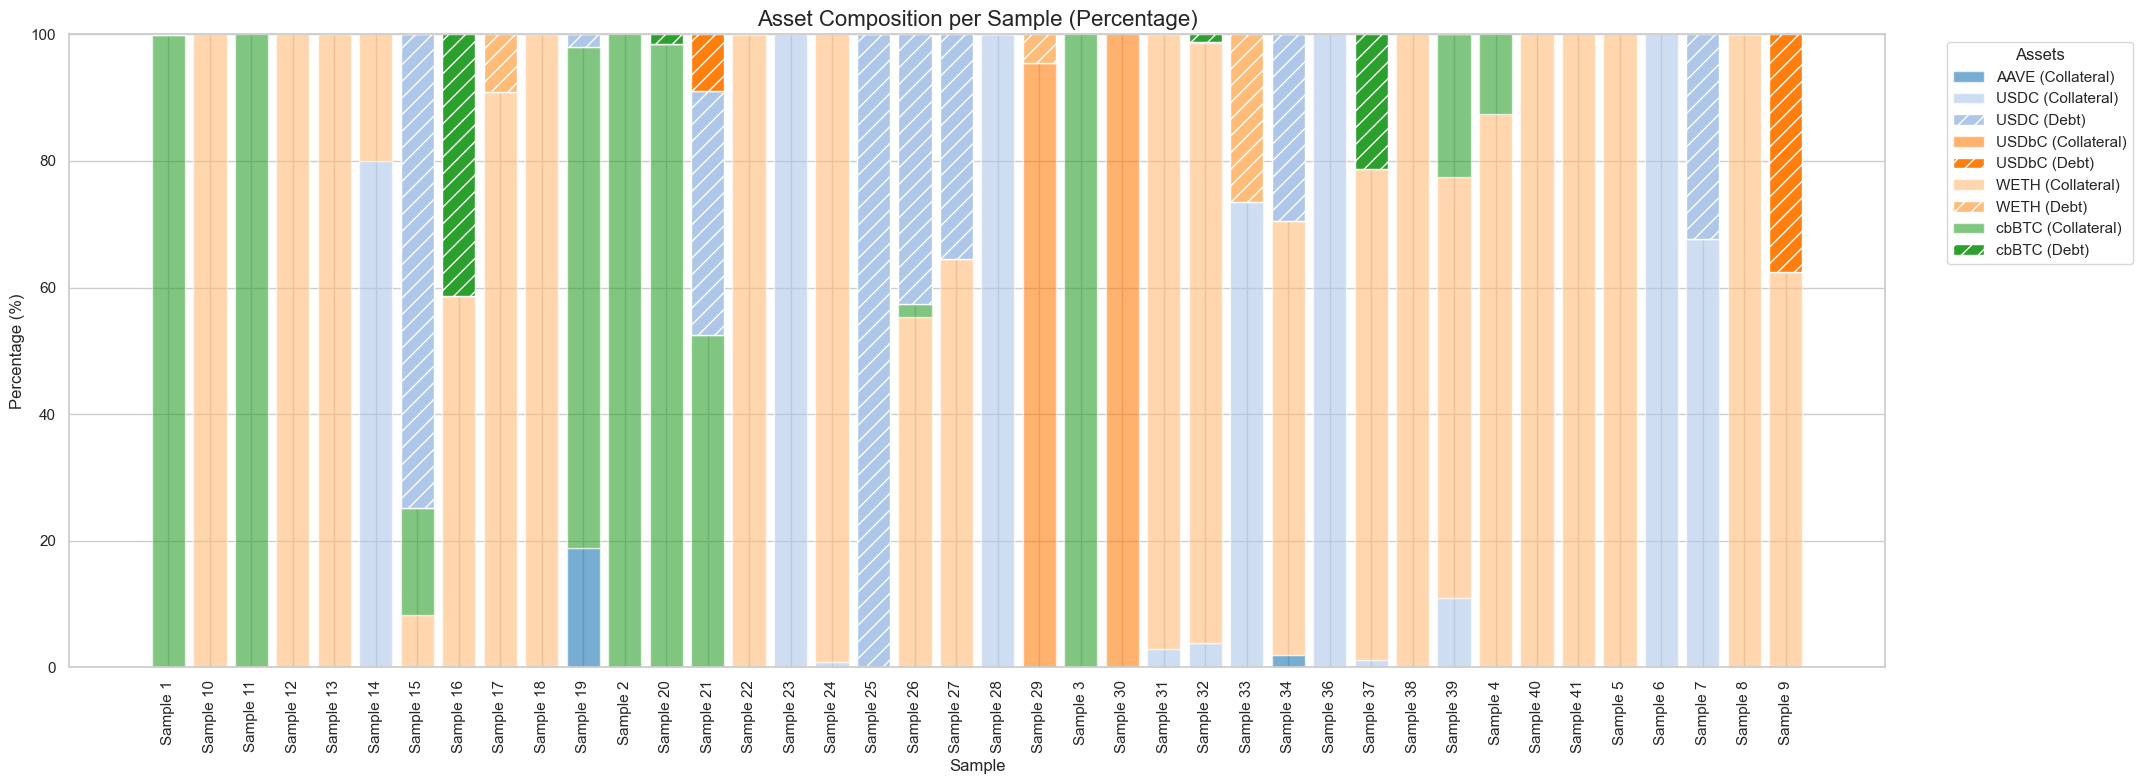

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import pandas as pd

print("--- 正在生成图表 3: 资产构成百分比 (100% 堆叠柱状图) ---")

# --- 1. 检查依赖数据 ---
if 'df_assets_long' not in locals() or df_assets_long.empty:
    print("错误：未找到 'df_assets_long' DataFrame。")
    print("请确保您已经成功运行了上一个单元格中的代码，以加载和处理 JSON 数据。")
else:
    # --- 2. 数据转换为百分比 ---
    
    # a. 计算每个 sample 的总市值 (抵押物 + 债务)
    df_totals = df_assets_long.groupby('sample_name')['value_eth_float'].sum().reset_index()
    df_totals = df_totals.rename(columns={'value_eth_float': 'total_value'})
    
    # b. 将总市值合并回原 DataFrame
    df_pct = df_assets_long.merge(df_totals, on='sample_name')
    
    # c. 计算百分比
    # 过滤掉总值为0的样本，避免除零错误
    df_pct = df_pct[df_pct['total_value'] > 0]
    df_pct['percentage'] = (df_pct['value_eth_float'] / df_pct['total_value']) * 100.0
    
    # --- 3. 准备绘图 ---
    
    # a. 获取唯一的样本和资产 (与上一个图表保持一致)
    unique_samples = sorted(df_pct['sample_name'].unique(), key=lambda x: int(x.split(' ')[1]))
    unique_assets = sorted(df_pct['asset_symbol'].unique())
    
    # b. 创建颜色映射 (与上一个图表保持一致)
    palette = sns.color_palette('tab20', n_colors=len(unique_assets))
    color_map = {asset: color for asset, color in zip(unique_assets, palette)}

    # c. 动态调整图表宽度
    chart_width = max(12, len(unique_samples) * 0.6)
    fig, ax = plt.subplots(figsize=(chart_width, 8))

    # d. 用于堆叠的底部追踪 (所有类型共享一个底部)
    bottoms = {sample: 0.0 for sample in unique_samples}
    
    # e. 排序以确保堆叠顺序一致 (先画抵押物，再画债务)
    df_plot = df_pct.sort_values(by=['sample_name', 'type', 'asset_symbol'], ascending=[True, True, True])

    # --- 4. 绘制堆叠柱状图 ---
    
    for _, row in df_plot.iterrows():
        sample = row['sample_name']
        symbol = row['asset_symbol']
        asset_type = row['type']
        percentage = row['percentage']
        color = color_map[symbol]
        
        # 根据类型设置样式
        alpha = 0.6 if asset_type == 'Collateral' else 1.0
        hatch = None if asset_type == 'Collateral' else '//'
        
        ax.bar(
            sample,
            percentage,
            bottom=bottoms[sample],
            color=color,
            alpha=alpha,
            hatch=hatch
        )
        # 更新该样本的底部
        bottoms[sample] += percentage

    # --- 5. 设置标签和图例 ---

    ax.set_title('Asset Composition per Sample (Percentage)', fontsize=16)
    ax.set_xlabel('Sample', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    
    # 锁定 Y 轴为 0-100
    ax.set_ylim(0, 100)
    
    # 如果样本太多，旋转标签
    if len(unique_samples) > 15:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    # 手动创建图例 (与上一个图表逻辑相同)
    legend_handles = []
    plotted_assets = df_plot.groupby(['asset_symbol', 'type']).size().reset_index().drop(0, axis=1)
    plotted_assets = plotted_assets.sort_values(by=['asset_symbol', 'type'])

    for _, row in plotted_assets.iterrows():
        symbol = row['asset_symbol']
        asset_type = row['type']
        color = color_map[symbol]
        
        if asset_type == 'Collateral':
            handle = Patch(
                facecolor=color,
                alpha=0.6,
                label=f"{symbol} (Collateral)"
            )
        else: # Debt
            handle = Patch(
                facecolor=color,
                alpha=1.0,
                hatch='//',
                label=f"{symbol} (Debt)"
            )
        legend_handles.append(handle)

    ax.legend(handles=legend_handles, title='Assets', bbox_to_anchor=(1.03, 1), loc='upper left')

    # 调整布局以适应图例
    fig.tight_layout(rect=[0, 0, 0.9, 1]) 
    
    plt.show() # 在 Notebook 中显示

## 最后筛选出的由于健康因子跌幅而造成的样本的分析

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from pathlib import Path
from decimal import Decimal, getcontext
import warnings
from matplotlib.patches import Patch # 导入 Patch 用于手动创建图例
import os

# --- 0. 设置 ---

print("--- 0. 正在设置环境 ---")
# 设置 Decimal 的精度以处理大型货币数字
getcontext().prec = 50

# 设置 Seaborn 样式
sns.set_theme(style="whitegrid")

# 忽略 Matplotlib 的 UserWarning (如果图例句柄过多)
warnings.filterwarnings("ignore", category=UserWarning)

# --- 1. 定义所有路径 ---

# "可达" (清算前 N-1) 样本的目录
REACH_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\Reach_and_unReach_sample\Reach")

# "清算后" (N) 样本的目录
POST_LIQ_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\reserves_picture_liqudation")

# 你要求的 CSV 输出目录
CSV_OUTPUT_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\Reach_and_unReach_sample")

# 用于保存所有图表的新目录
PLOT_OUTPUT_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\Reach_samples_visualizations")

# 确保输出目录存在
CSV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# --- 2. (任务 1) 创建“可达样本”CSV ---

print(f"\n--- 1. 正在从 {REACH_DIR} 提取元数据 ---")

reach_samples_metadata = []
# 获取所有在 Reach 目录中的 JSON 文件名
reach_filenames = [f for f in os.listdir(REACH_DIR) if f.endswith('.json')]
print(f"找到了 {len(reach_filenames)} 个 'Reach' 样本。")

for filename in reach_filenames:
    file_path = REACH_DIR / filename
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 提取关键元数据
    reach_samples_metadata.append({
        "txHash": data.get('txHash'),
        "user_id": data.get('user_id'),
        "liquidation_timestamp": data.get('liquidation_timestamp'),
        "last_action_timestamp": data.get('last_action_timestamp'),
        "health_factor": data.get('health_factor'),
        "filename": filename
    })

# 转换为 DataFrame
df_reach_samples = pd.DataFrame(reach_samples_metadata)
csv_output_path = CSV_OUTPUT_DIR / "analyzed_reach_samples.csv"
df_reach_samples.to_csv(csv_output_path, index=False, encoding='utf-8')

print(f"已将“可达样本”列表保存到: {csv_output_path}")


# --- 3. 定义数据处理和绘图的辅助函数 ---

def calculate_eth_value(balance_str, price_str, decimals):
    """
    使用 Decimal 精确计算 ETH 市值。
    """
    try:
        balance_wei = Decimal(balance_str)
        price_in_eth_wei = Decimal(price_str)
        
        if balance_wei == 0 or price_in_eth_wei == 0:
            return Decimal(0)
            
        denominator_decimals = Decimal(10) ** int(decimals)
        denominator_price = Decimal(10) ** 18
        
        value_eth = (balance_wei * price_in_eth_wei) / (denominator_decimals * denominator_price)
        return value_eth
        
    except Exception as e:
        print(f"警告: 计算市值时出错 (balance: {balance_str}, price: {price_str}, decimals: {decimals}). 错误: {e}")
        return Decimal(0)

def process_and_plot_snapshots(json_directory, file_list, snapshot_key, plot_suffix):
    """
    一个可重用的函数，用于加载、处理和绘制来自一组 JSON 文件的快照数据。
    :param json_directory: (Path) 要读取的 JSON 文件所在的目录。
    :param file_list: (list) 要处理的文件名列表 (例如: ['txhash1.json', ...])。
    :param snapshot_key: (str) JSON 中包含资产列表的键 (例如: 'pre_liquidation_snapshot')。
    :param plot_suffix: (str) 附加到保存的图表文件名的后缀 (例如: '_PRE_Liquidation')。
    """
    
    print(f"\n--- 开始分析: {plot_suffix.replace('_', ' ')} ---")
    print(f"数据源: {json_directory}")
    print(f"快照键: {snapshot_key}")

    all_samples_data = []
    all_assets_data = []

    # 按文件名对列表进行排序，以确保 "Sample 1", "Sample 2" 是一致的
    sorted_file_list = sorted(file_list)

    for i, filename in enumerate(sorted_file_list):
        sample_name = f"Sample {i + 1}"
        file_path = json_directory / filename
        
        if not file_path.exists():
            print(f"警告: 在 {json_directory} 中找不到文件 {filename}，跳过。")
            continue
            
        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                print(f"警告: 跳过 {file_path}，因为文件 JSON 格式无效。")
                continue

        # 1. 计算时间间隔
        try:
            liquidation_ts = Decimal(data['liquidation_timestamp'])
            last_action_ts = Decimal(data['last_action_timestamp'])
            time_diff_seconds = float(liquidation_ts - last_action_ts)
            time_diff_hours = time_diff_seconds / 3600.0
        except (KeyError, TypeError):
            print(f"警告: 跳过 {sample_name} 的时间计算，缺少时间戳。")
            time_diff_hours = 0.0

        # 2. 计算抵押物和债务
        if snapshot_key not in data:
            print(f"警告: 跳过 {sample_name} ({filename})，缺少 '{snapshot_key}' 键。")
            continue
            
        # *** 关键：使用传入的 snapshot_key ***
        for asset in data[snapshot_key]:
            try:
                symbol = asset['reserve']['symbol']
                decimals = asset['reserve']['decimals']
                price_eth_str = asset['reserve']['price']['priceInEth']
                is_collateral = asset['usageAsCollateralEnabledOnUser']
                
                balance_str = asset['currentATokenBalance']
                debt_str = asset['currentTotalDebt']

                # 计算抵押物价值
                collateral_value_eth = calculate_eth_value(balance_str, price_eth_str, decimals)
                if is_collateral and collateral_value_eth > 0:
                    all_assets_data.append({
                        "sample_name": sample_name,
                        "asset_symbol": symbol,
                        "value_eth_float": float(collateral_value_eth),
                        "type": "Collateral"
                    })

                # 计算债务价值
                debt_value_eth = calculate_eth_value(debt_str, price_eth_str, decimals)
                if debt_value_eth > 0:
                    all_assets_data.append({
                        "sample_name": sample_name,
                        "asset_symbol": symbol,
                        "value_eth_float": float(debt_value_eth),
                        "type": "Debt"
                    })
                    
            except (KeyError, TypeError) as e:
                print(f"警告: 处理 {sample_name} 中的资产时出错 (Symbol: {asset.get('reserve', {}).get('symbol', 'N/A')}). 错误: {e}")

        all_samples_data.append({
            "sample_name": sample_name,
            "time_diff_hours": time_diff_hours
        })

    # --- 3. 转换为 DataFrame ---
    df_samples = pd.DataFrame(all_samples_data)
    df_assets_long = pd.DataFrame(all_assets_data)

    if df_samples.empty or df_assets_long.empty:
        print(f"未能在 {plot_suffix} 分析中加载任何有效数据。跳过绘图。")
        return

    # --- 4. 可视化 1: 时间间隔柱状图 ---
    print(f"  -> 正在生成 图表 1{plot_suffix}...")
    num_samples_1 = len(df_samples['sample_name'].unique())
    chart_width_1 = max(10, num_samples_1 * 0.5)
    plt.figure(figsize=(chart_width_1, 6))
    
    df_samples_sorted = df_samples.sort_values('time_diff_hours', ascending=False)
    ax1 = sns.barplot(data=df_samples_sorted, x='sample_name', y='time_diff_hours', color='steelblue')
    ax1.set_title(f'Time Interval from Last Action to Liquidation{plot_suffix}', fontsize=16)
    ax1.set_xlabel('Sample', fontsize=12)
    ax1.set_ylabel('Time Interval (Hours)', fontsize=12)
    
    if num_samples_1 > 15:
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
    
    plt.tight_layout()
    plt.savefig(PLOT_OUTPUT_DIR / f"plot1_time_interval{plot_suffix}.png", bbox_inches='tight')
    plt.close() # 关闭图表以释放内存

    # --- 5. 可视化 2: 抵押物/债务堆叠柱状图 (绝对值) ---
    print(f"  -> 正在生成 图表 2{plot_suffix}...")
    unique_samples = sorted(df_assets_long['sample_name'].unique(), key=lambda x: int(x.split(' ')[1]))
    unique_assets = sorted(df_assets_long['asset_symbol'].unique())
    
    palette = sns.color_palette('tab20', n_colors=len(unique_assets))
    color_map = {asset: color for asset, color in zip(unique_assets, palette)}

    chart_width_2 = max(12, len(unique_samples) * 0.6)
    fig, ax = plt.subplots(figsize=(chart_width_2, 8))

    collateral_bottoms = {sample: 0.0 for sample in unique_samples}
    debt_bottoms = {sample: 0.0 for sample in unique_samples}
    
    # 绘制抵押物
    df_collateral = df_assets_long[df_assets_long['type'] == 'Collateral']
    for _, row in df_collateral.iterrows():
        sample, symbol, value = row['sample_name'], row['asset_symbol'], row['value_eth_float']
        ax.bar(sample, value, bottom=collateral_bottoms[sample], color=color_map[symbol], alpha=0.6)
        collateral_bottoms[sample] += value

    # 绘制债务
    df_debt = df_assets_long[df_assets_long['type'] == 'Debt']
    for _, row in df_debt.iterrows():
        sample, symbol, value = row['sample_name'], row['asset_symbol'], row['value_eth_float']
        ax.bar(sample, value, bottom=debt_bottoms[sample], color=color_map[symbol], alpha=1.0, hatch='//')
        debt_bottoms[sample] += value

    ax.set_title(f'Collateral and Debt Value per Sample (in ETH){plot_suffix}', fontsize=16)
    ax.set_xlabel('Sample', fontsize=12)
    ax.set_ylabel('Value (ETH)', fontsize=12)
    
    if len(unique_samples) > 15:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    # 手动创建图例
    legend_handles = []
    plotted_assets = df_assets_long.groupby(['asset_symbol', 'type']).size().reset_index().drop(0, axis=1)
    plotted_assets = plotted_assets.sort_values(by=['asset_symbol', 'type'])

    for _, row in plotted_assets.iterrows():
        symbol, asset_type = row['asset_symbol'], row['type']
        color = color_map[symbol]
        if asset_type == 'Collateral':
            handle = Patch(facecolor=color, alpha=0.6, label=f"{symbol} (Collateral)")
        else:
            handle = Patch(facecolor=color, alpha=1.0, hatch='//', label=f"{symbol} (Debt)")
        legend_handles.append(handle)

    ax.legend(handles=legend_handles, title='Assets', bbox_to_anchor=(1.03, 1), loc='upper left')
    fig.tight_layout(rect=[0, 0, 0.9, 1]) 
    plt.savefig(PLOT_OUTPUT_DIR / f"plot2_absolute_values{plot_suffix}.png", bbox_inches='tight')
    plt.close() # 关闭图表

    # --- 6. 可视化 3: 资产构成百分比 (100% 堆叠) ---
    print(f"  -> 正在生成 图表 3{plot_suffix}...")
    
    # a. 计算百分比
    df_totals = df_assets_long.groupby('sample_name')['value_eth_float'].sum().reset_index()
    df_totals = df_totals.rename(columns={'value_eth_float': 'total_value'})
    df_pct = df_assets_long.merge(df_totals, on='sample_name')
    df_pct = df_pct[df_pct['total_value'] > 0]
    df_pct['percentage'] = (df_pct['value_eth_float'] / df_pct['total_value']) * 100.0
    
    # b. 绘图
    chart_width_3 = max(12, len(unique_samples) * 0.6)
    fig, ax = plt.subplots(figsize=(chart_width_3, 8))

    bottoms_pct = {sample: 0.0 for sample in unique_samples}
    df_plot_pct = df_pct.sort_values(by=['sample_name', 'type', 'asset_symbol'], ascending=[True, True, True])

    for _, row in df_plot_pct.iterrows():
        sample, symbol, asset_type, percentage = row['sample_name'], row['asset_symbol'], row['type'], row['percentage']
        color = color_map[symbol]
        alpha = 0.6 if asset_type == 'Collateral' else 1.0
        hatch = None if asset_type == 'Collateral' else '//'
        
        ax.bar(sample, percentage, bottom=bottoms_pct[sample], color=color, alpha=alpha, hatch=hatch)
        bottoms_pct[sample] += percentage

    # c. 设置标签和图例
    ax.set_title(f'Asset Composition per Sample (Percentage){plot_suffix}', fontsize=16)
    ax.set_xlabel('Sample', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_ylim(0, 100)
    
    if len(unique_samples) > 15:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    # (使用与图2相同的图例句柄)
    ax.legend(handles=legend_handles, title='Assets', bbox_to_anchor=(1.03, 1), loc='upper left')
    fig.tight_layout(rect=[0, 0, 0.9, 1]) 
    plt.savefig(PLOT_OUTPUT_DIR / f"plot3_percentage_composition{plot_suffix}.png", bbox_inches='tight')
    plt.close() # 关闭图表


# --- 4. (任务 2 & 3) 执行分析 ---

# 运行清算前 (PRE-Liquidation) 的分析
process_and_plot_snapshots(
    json_directory=REACH_DIR,
    file_list=reach_filenames,
    snapshot_key='pre_liquidation_snapshot',
    plot_suffix='_PRE_Liquidation'
)

# 运行清算后 (POST-Liquidation) 的分析
# 注意：我们使用相同的 reach_filenames 列表，但从 POST_LIQ_DIR 读取
process_and_plot_snapshots(
    json_directory=POST_LIQ_DIR,
    file_list=reach_filenames,
    snapshot_key='liquidation_snapshot',
    plot_suffix='_POST_Liquidation'
)

print(f"\n--- 所有分析和绘图已完成 ---")
print(f"分析列表已保存到: {csv_output_path}")
print(f"所有 6 个图表已保存到: {PLOT_OUTPUT_DIR}")

C:\Users\10158\AppData\Roaming\Python\Python310\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


--- 0. 正在设置环境 ---

--- 1. 正在从 F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\Reach_and_unReach_sample\Reach 提取元数据 ---
找到了 16 个 'Reach' 样本。
已将“可达样本”列表保存到: F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\Reach_and_unReach_sample\analyzed_reach_samples.csv

--- 开始分析:  PRE Liquidation ---
数据源: F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\Reach_and_unReach_sample\Reach
快照键: pre_liquidation_snapshot
  -> 正在生成 图表 1_PRE_Liquidation...
  -> 正在生成 图表 2_PRE_Liquidation...
  -> 正在生成 图表 3_PRE_Liquidation...

--- 开始分析:  POST Liquidation ---
数据源: F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\01_reserve_capture\data\reserves_picture_liqudation
快照键: liquidation_snapshot
  -> 正在生成 图表 1_POST_Liqui